# Run some experiments with parameters to see if grokking occurs in PINNs

Omnigrok suggests I should lower the training data, and increase testing. Another point is to increase the weights. 

In [23]:
from functools import partial
from typing import Union

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from matplotlib import pyplot as plt
from tqdm import tqdm

import sys
sys.path.append('../../utils')
sys.path.append('../../data')
sys.path.append('../../models')


from MLP import MLP_1D
from cg import conjugate_gradient
from data_utils import batch_data_pinns, generate_training_data
from jacobian_tools import flatten_jacobian
from model_utils import create_train_state
from plotting import plot_results_pinns

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

from run_pinns import *

In [24]:
def generate_training_data_train(num_interior: int, num_boundary: int, seed: int=0):
    """
    Generate training data 

    Args:
        num_interior (int): number of interior points
        num_boundary (int): number of boundary points
        seed (int, optional): Seed. Defaults to 0.
    """
    key = jax.random.PRNGKey(seed)

    # Generate interior points 
    key, subkey = jax.random.split(key)
    interior_points = jax.random.uniform(subkey, (num_interior, 2))

    # Generate boundary points 
    key, subkey = jax.random.split(key)
    boundary_points_1 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([1, 0])
    key, subkey = jax.random.split(key)
    boundary_points_2 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([1, 0]) + jnp.array([0, 1])
    key, subkey = jax.random.split(key)
    boundary_points_3 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([0, 1])
    key, subkey = jax.random.split(key)
    boundary_points_4 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([0, 1]) + jnp.array([1, 0])

    boundary_points = jnp.concatenate([boundary_points_1, boundary_points_2, boundary_points_3, boundary_points_4], axis=0)

    return interior_points, boundary_points

def generate_training_data_test(num_interior: int, num_boundary: int, seed: int=0):
    """
    Generate training data 

    Args:
        num_interior (int): number of interior points
        num_boundary (int): number of boundary points
        seed (int, optional): Seed. Defaults to 0.
    """
    key = jax.random.PRNGKey(seed)

    # Generate interior points 
    key, subkey = jax.random.split(key)
    interior_points = jax.random.uniform(subkey, (num_interior, 2))

    # Generate boundary points 
    key, subkey = jax.random.split(key)
    boundary_points_1 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([1, 0])
    key, subkey = jax.random.split(key)
    boundary_points_2 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([1, 0]) + jnp.array([0, 1])
    key, subkey = jax.random.split(key)
    boundary_points_3 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([0, 1])
    key, subkey = jax.random.split(key)
    boundary_points_4 = jax.random.uniform(subkey, (num_boundary // 4, 2)) * jnp.array([0, 1]) + jnp.array([1, 0])

    boundary_points = jnp.concatenate([boundary_points_1, boundary_points_2, boundary_points_3, boundary_points_4], axis=0)

    return interior_points, boundary_points

In [41]:
num_interior = 80 * 1
num_boundary = 20 * 1
interior_points, boundary_points = generate_training_data_train(num_interior, num_boundary)

interior_points_test, boundary_points_test = generate_training_data_test(num_interior * 20, num_boundary * 20)


In [55]:
dims = 256
model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=1e-3, momentum=0, optimizer='adam', shape=jnp.ones((1, 2)))

In [56]:
n, m = 1, 1
state, metrics_history_sgd_11 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=100000,
                                     lm_schedule=None,
                                     forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=100, 
                                    test_data=(interior_points_test, boundary_points_test)
                                     )

  0%|                | 0/100000 [00:00<?, ?it/s]

(80, 2) (20, 2)


100%|█| 100000/100000 [06:36<00:00, 252.34it/s, 


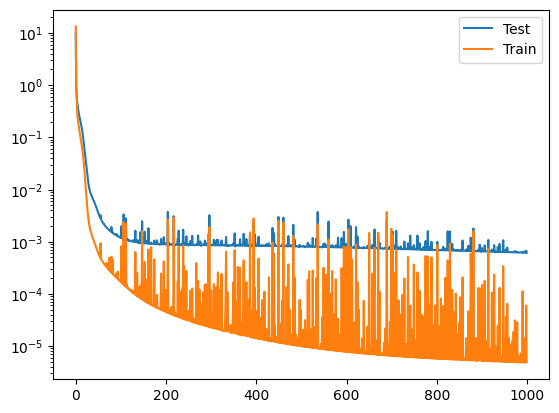

In [57]:
plt.semilogy(
    metrics_history_sgd_11['test_loss']
)
plt.semilogy(
    metrics_history_sgd_11['train_loss'][::100]
)
plt.legend(['Test', 'Train'])

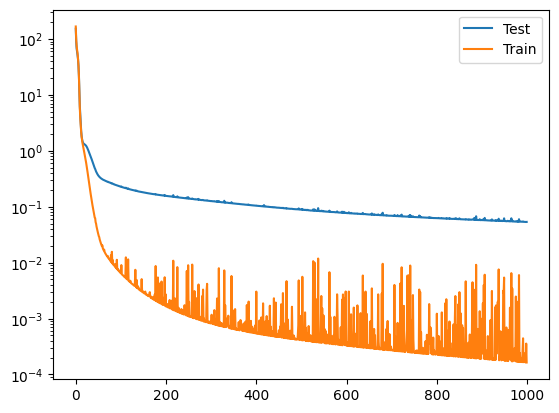

In [44]:
plt.semilogy(
    metrics_history_sgd_11['test_loss']
)
plt.semilogy(
    metrics_history_sgd_11['train_loss'][::100]
)
plt.legend(['Test', 'Train'])

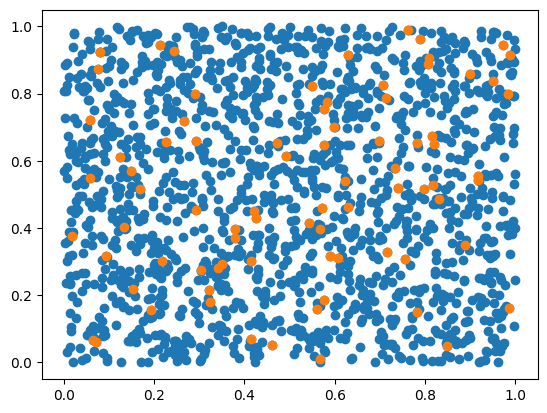

In [48]:
plt.scatter(interior_points_test[:, 0], interior_points_test[:, 1])
plt.scatter(interior_points[:, 0], interior_points[:, 1])